# 数据集加载及预处理

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np

# 加载加利福尼亚房价数据集
california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

# 先划分数据集，然后在训练集上fit标准化器
from sklearn.model_selection import train_test_split

# 首先划分训练集和临时集（验证集+测试集）
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 再将临时集划分为验证集和测试集
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 数据标准化（只对特征进行标准化，标签不进行标准化）
# 在训练集上fit_transform，验证集和测试集只进行transform
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# 自定义Dataset类
class CaliforniaHousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return (self.X[idx],self.X[idx][-2:]), self.y[idx].unsqueeze(0)

# 创建数据集
train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

# 创建DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"数据集大小: 总计 {len(X)}")
print(f"训练集: {len(train_dataset)} 样本")
print(f"验证集: {len(val_dataset)} 样本")
print(f"测试集: {len(test_dataset)} 样本")
print(f"特征维度: {X.shape[1]}")


数据集大小: 总计 20640
训练集: 14448 样本
验证集: 3096 样本
测试集: 3096 样本
特征维度: 8


In [2]:
for (x1,x2),y in train_loader:
    print(x1.shape)
    print(x2.shape)
    print(y.shape)
    break

torch.Size([64, 8])
torch.Size([64, 2])
torch.Size([64, 1])


In [3]:


# 演示批量情况
print(f"\n批量情况演示:")
y_batch = torch.tensor([1.2, 2.3, 3.4])  # 3个样本的标签
print(f"批量标签原始形状: {y_batch.shape}")
y_batch_unsqueezed = y_batch.unsqueeze(1)  # 在第1维增加维度
print(f"批量标签unsqueeze(1)后形状: {y_batch_unsqueezed.shape}")
print(f"批量标签内容:\n{y_batch_unsqueezed}")



批量情况演示:
批量标签原始形状: torch.Size([3])
批量标签unsqueeze(1)后形状: torch.Size([3, 1])
批量标签内容:
tensor([[1.2000],
        [2.3000],
        [3.4000]])


# 搭建模型

In [4]:
class WideDeep(nn.Module):
    def __init__(self, input_dim=(8,2)):
        # input_dim=(8,2) 表示wide部分和deep部分的输入特征数分别为8和2，是一个元组；
        # 而 input_dim=8 只是一个整数，代表只有wide部分的特征数，这不适用于多输入场景。
        # 在wide & deep结构中，应该用元组分别指定两部分的输入特征维度，便于结构自适应数据。

        # 多输入模型常用于每个样本由不同来源或不同类型的特征组成的情况，
        # 比如 wide & deep 结构，通常用于结合"线性特征工程"和"深度非线性特征"。
        #   - 需要多输入: 样本的特征可以自然分为两（多）组、各自语义明显，比如分类特征/数值特征分开处理。
        #                 推荐系统大多采用 wide（手工组合特征） 和 deep（原始稠密特征/嵌入）两路输入。
        #   - 不需要多输入: 样本的所有特征可以直接组合在一个tensor（如 tabular 所有特征都可拼在一起），
        #                   或者对所有特征采用相同的处理方式（如全连接/卷积），用单输入模型更简单高效。


        # 是的，在本例中没有进行人工交叉特征的操作。
        # 一般来说，“人工交叉特征”是指我们手动对原有特征做乘积、组合等处理，例如 feature1 * feature2 或 feature1 + feature3 这种，把它们拼接到原始特征里，这属于“特征工程”的类别，常用于提升简单模型表现。
        # 在当前WideDeep的结构里，虽然有wide部分和deep部分输入，但wide部分只是直接输入原始特征（X_wide），没有人为地对wide输入做一系列交叉构造（比如添加 x1*x2、x3+x4 等新组合）。
        # 换句话说，这里的wide仅是“原始特征的线性部分”，而不是“含有交叉特征的wide部分”。
        # 实际业务中，如果要体现“人工交叉”，通常会在wide部分输入张量中拼入你手工交叉出来的这些特征，代码上就体现在 X_wide 里包含了交叉列，模型结构不需要特殊更改。
        # 结论：本例未做人工交叉，只是保留了WideDeep结构，如何用人工交叉可见文档注释说明。
        
        """
        初始化 Wide & Deep 模型。
        参数:
            input_dim: 一个元组，(wide部分输入特征数, deep部分输入特征数)。
                      如 (8,2) 表示 wide部分8维，deep部分2维。
        """

        super().__init__()
        # 构建 Deep 部分（多层感知机），输入为 deep 部分的特征（如2维），输出为30维
        self.deep = nn.Sequential(
            nn.Linear(input_dim[1], 30),  # 第一层，输入为deep特征数，输出30个神经元
            nn.ReLU(),                    # 激活函数
            nn.Linear(30, 30),            # 第二层，输入30，输出30（堆叠一层隐藏层）
            nn.ReLU()                     # 激活函数
        )
        # Wide & Deep拼接后作为输出层输入
        # 输出层的输入特征数为 wide部分特征数 + deep最后一层输出的特征数
        self.output_layer = nn.Linear(30 + input_dim[0], 1)  # 输出为1维（回归任务）
        
        # 初始化权重
        self.init_weights()
        
    def init_weights(self):
        """
        使用 Xavier 均匀分布初始化所有的全连接层权重，并将偏置初始化为0。
        """
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
        
    def forward(self, x_wide, x_deep):
        """
        前向传播过程。
        输入:
            x_wide: wide部分的输入特征，形状为 [batch_size, wide特征数]
            x_deep: deep部分的输入特征，形状为 [batch_size, deep特征数]
        输出:
            logits: 预测结果，形状为 [batch_size, 1]
        """
        # 通过 deep 网络获取深层特征，deep_output形状为 [batch_size, 30]
        deep_output = self.deep(x_deep)
        # 将 wide（形状[batch_size, wide特征数]）与 deep 输出（[batch_size, 30]）拼接
        # 拼接后得到 [batch_size, wide特征数+30]（如[batch_size, 38]）
        concat = torch.cat([x_wide, deep_output], dim=1)
        # 拼接后的特征输入到输出层，得到最终预测 logits
        logits = self.output_layer(concat)  # 输出形状 [batch_size, 1]
        return logits


In [5]:
# 编写前向计算验证上面模型

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 实例化模型，并移动到设备
model = WideDeep(input_dim=(8,2)).to(device)

# 创建模拟输入：wide部分(batch, 8)，deep部分(batch, 2)
x_wide = torch.randn(4, 8).to(device)
x_deep = torch.randn(4, 2).to(device)

# 前向计算，得到输出
output = model(x_wide, x_deep)

print(f"x_wide形状: {x_wide.shape}")
print(f"x_deep形状: {x_deep.shape}")
print(f"模型输出形状: {output.shape}")
print(f"模型输出内容:\n{output}")


使用设备: cpu
x_wide形状: torch.Size([4, 8])
x_deep形状: torch.Size([4, 2])
模型输出形状: torch.Size([4, 1])
模型输出内容:
tensor([[ 1.4942],
        [-0.6446],
        [ 0.3667],
        [ 0.0598]], grad_fn=<AddmmBackward0>)


In [7]:
@torch.no_grad()  # 关闭梯度计算，加快推理速度且节省内存（用于评估和验证阶段）
def evaluating(model, dataloader, loss_fct):
    """
    评估模型在给定dataloader上的平均损失。
    
    Args:
        model: 待评估的模型，需实现forward(x_wide, x_deep)方法
        dataloader: 验证数据加载器，返回((datas_wide, datas_deep), labels)格式的数据
        loss_fct: 损失函数（如nn.MSELoss）

    Returns:
        验证集上的平均损失（float）
    """
    loss_list = []  # 存储每个batch的损失

    # 遍历验证数据集
    for (datas_wide, datas_deep), labels in dataloader:
        # 将数据转移到与模型相同的设备（如cuda/cpu），以确保计算一致
        datas_deep = datas_deep.to(device)
        datas_wide = datas_wide.to(device)
        labels = labels.to(device)

        # 前向计算，得到模型输出logits
        logits = model(datas_wide, datas_deep)

        # 计算当前batch的损失值
        loss = loss_fct(logits, labels)  # 验证集损失
        loss_list.append(loss.item())    # 转为float并加入损失列表

    # 求取所有batch损失的均值，作为整体平均损失返回
    return np.mean(loss_list)

In [8]:
# 导入训练模块，包括自定义的Trainer类以及EarlyStopping、ModelCheckpoint等工具（回归训练可用原生训练或定制Trainer）
from wangdao_train import Trainer, EarlyStopping, ModelCheckpoint

# 需要安装tqdm库，用于实现训练进度条的显示，可通过 'pip install tqdm' 安装
from tqdm.auto import tqdm

# 初始化损失函数（均方误差MSE，适合回归问题）
criterion = nn.MSELoss()  # 定义损失函数，常用于回归任务

# 初始化优化器，采用Adam算法并设置学习率为0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练函数，包含训练、验证和曲线记录功能
def training(
    model,                      # 要训练的模型
    train_loader,               # 训练数据集的加载器，支持wide & deep两输入
    val_loader,                 # 验证数据集的加载器
    epoch,                      # 总迭代轮数
    loss_fct,                   # 损失函数
    optimizer,                  # 优化器
    tensorboard_callback=None,  # （可选）TensorBoard日志回调
    save_ckpt_callback=None,    # （可选）模型保存回调
    early_stop_callback=None,   # （可选）早停回调
    eval_step=500,              # 每隔多少step在验证集上评估一次
    ):
    record_dict = {
        "train": [],    # 训练集每步损失的记录
        "val": []       # 验证集评估点的损失记录
    }
    
    global_step = 0                    # 训练步数计数器
    model.train()                      # 切换到训练模式
    with tqdm(total=epoch * len(train_loader)) as pbar:  # tqdm为训练进度条
        for epoch_id in range(epoch):  # 外层循环: 逐个epoch训练
            # 遍历每个batch
            for (datas_wide, datas_deep), labels in train_loader:  # unpack: wide和deep特征 & 标签
                # 数据转到与模型相同的设备
                datas_deep = datas_deep.to(device)
                datas_wide = datas_wide.to(device)
                labels = labels.to(device)
                # 梯度清零
                optimizer.zero_grad()
                # 前向传播，根据模型forward(x_wide, x_deep)
                logits = model(datas_wide, datas_deep)
                # 计算本batch损失
                loss = loss_fct(logits, labels)
                # 反向传播
                loss.backward()
                # 优化器参数更新
                optimizer.step()
                # 获取loss的cpu浮点值（防止显存泄漏）
                loss = loss.cpu().item()
                # 记录训练损失及步数
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })
                
                # 按eval_step周期做一次验证集评估
                if global_step % eval_step == 0:
                    model.eval()  # 切换到评估模式
                    val_loss = evaluating(model, val_loader, loss_fct)  # 验证损失
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step
                    })
                    model.train()  # 恢复训练模式
                    
                # 步数+1
                global_step += 1
                # tqdm进度条更新
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})  # 显示当前epoch编号
        
    return record_dict  # 返回训练&验证损失轨迹，用于后续分析及绘图
        

epoch = 10  # 训练轮数，可根据实际情况调整

# 将模型转移到指定设备（如GPU或CPU）
model = model.to(device)
# 调用训练函数，传入全部参数
record = training(
    model, 
    train_loader, 
    val_loader, 
    epoch, 
    criterion, 
    optimizer,
    eval_step=len(train_loader)   # 每个epoch评估1次验证集
    )

  0%|          | 0/2260 [00:00<?, ?it/s]

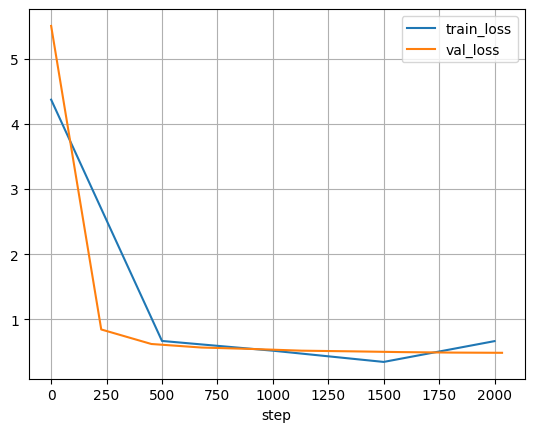

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=500):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # plot
    for idx, item in enumerate(train_df.columns):
        plt.plot(train_df.index, train_df[item], label=f"train_{item}")
        plt.plot(val_df.index, val_df[item], label=f"val_{item}")
        plt.grid()
        plt.legend()
        # plt.xticks(range(0, train_df.index[-1], 10*sample_step), range(0, train_df.index[-1], 10*sample_step))
        plt.xlabel("step")

        plt.show()

plot_learning_curves(record, sample_step=500)  #横坐标是 steps